# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

### Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

> **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required.

---

### 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

---

### 2. Project Objectives

* Understand the structure and quality of the agricultural dataset.
* Clean and prepare the data for analysis.
* Explore seasonal patterns in the dataset.
* Perform descriptive and statistical analysis.
* Investigate relationships among relevant variables.
* Compare agricultural performance across seasons and other meaningful groups.
* Use appropriate univariate, bivariate, and multivariate visualizations.
* Identify significant findings from the data.
* Develop evidence-based insights and recommendations.

---

### 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit, and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`


In [13]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

# Set visualization theme and pandas formatting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# Load the dataset
file_path = "seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_path)

# Verify dataset loading
print("Dataset loaded successfully.")
print("Dataset Shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display initial rows
df.head()

Dataset loaded successfully.
Dataset Shape: (4000, 28)
Number of rows: 4000
Number of columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


### 3. Data Quality & Structure Inspection

Evaluate dataset attributes, check data types, count missing values, and review preliminary summary statistics.

In [14]:
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
df.describe().T

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha      

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,3952.00,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,3960.00,26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00


### 4. Data Preprocessing & Feature Engineering

Clean missing values using season-specific medians and calculate key financial indicators (ROI, Profit Margin, Cost per Hectare).

In [15]:
# Impute missing values using seasonal median
impute_cols = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]
for col in impute_cols:
  if col in df.columns:
    df[col] = df.groupby("Season")[col].transform(
        lambda x: x.fillna(x.median())
    )

# Calculate financial indicators
if "Total_Cost_INR" in df.columns and "Revenue_INR" in df.columns:
  df["ROI_pct"] = (
      (df["Revenue_INR"] - df["Total_Cost_INR"]) / df["Total_Cost_INR"]
  ) * 100

if "Profit_INR" in df.columns and "Revenue_INR" in df.columns:
  df["Profit_Margin_pct"] = (df["Profit_INR"] / df["Revenue_INR"]) * 100

if "Total_Cost_INR" in df.columns and "Farm_Area_Hectares" in df.columns:
  df["Cost_Per_Hectare"] = df["Total_Cost_INR"] / df["Farm_Area_Hectares"]

print("Missing Values Check Post-Imputation:")
print(df.isnull().sum())

Missing Values Check Post-Imputation:
Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk

### 5. Seasonal Aggregation & Summary

Group performance records by agricultural season (`Kharif`, `Rabi`, `Zaid`) to calculate group averages across key indicators.

In [16]:
seasonal_summary = (
    df.groupby("Season")
    .agg(
        Record_Count=(
            "Farm_ID" if "Farm_ID" in df.columns else df.columns[0],
            "count",
        ),
        Avg_Yield=("Yield_Tonnes_Ha", "mean"),
        Avg_Rainfall=("Rainfall_mm", "mean"),
        Avg_Temp=("Avg_Temperature_C", "mean"),
        Avg_Cost=("Total_Cost_INR", "mean"),
        Avg_Revenue=("Revenue_INR", "mean"),
        Avg_Profit=("Profit_INR", "mean"),
        Avg_ROI=("ROI_pct", "mean"),
    )
    .reset_index()
)

seasonal_summary

,Season,Record_Count,Avg_Yield,Avg_Rainfall,Avg_Temp,Avg_Cost,Avg_Revenue,Avg_Profit,Avg_ROI
0,Kharif,1779,5.63,852.11,28.45,531804.41,710719.06,178914.65,35.45
1,Rabi,1627,5.04,435.94,23.49,513836.58,601526.05,87689.47,17.60
2,Zaid,594,4.64,299.12,31.04,543976.73,519171.90,-24804.82,-2.47


### 6. Visual Data Analysis

#### 6.1 Univariate Analysis: Yield Spread by Season
Examine the variance and distribution of agricultural yield per hectare across seasons.

/tmp/ipykernel_653/2794537126.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="Set2")


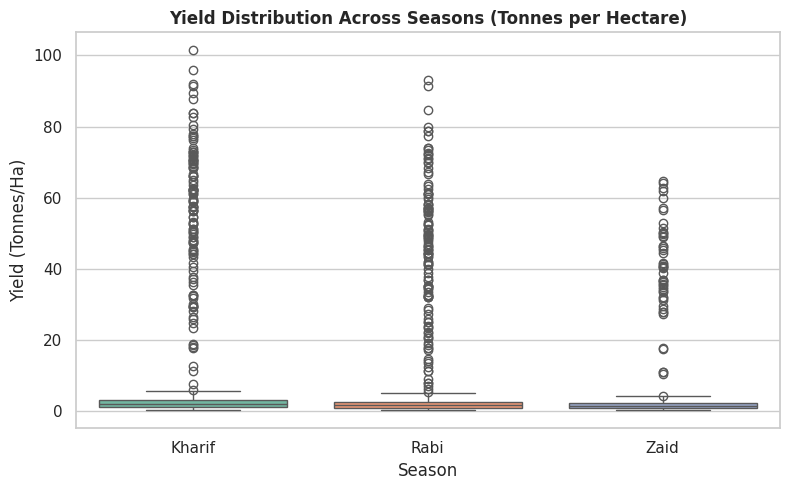

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="Set2")
plt.title(
    "Yield Distribution Across Seasons (Tonnes per Hectare)", fontweight="bold"
)
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

#### 6.2 Bivariate Analysis: Crop Profitability
Compare average net profit outcomes across individual crop varieties.

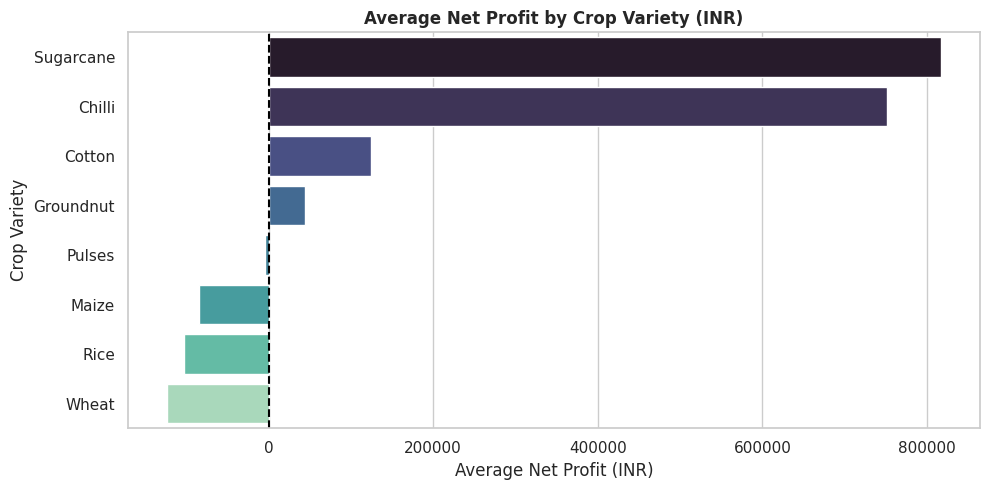

In [18]:
crop_performance = (
    df.groupby("Crop")["Profit_INR"]
    .mean()
    .reset_index()
    .sort_values(by="Profit_INR", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=crop_performance,
    x="Profit_INR",
    y="Crop",
    hue="Crop",
    palette="mako",
    legend=False,
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Average Net Profit by Crop Variety (INR)", fontweight="bold")
plt.xlabel("Average Net Profit (INR)")
plt.ylabel("Crop Variety")
plt.tight_layout()
plt.show()

#### 6.3 Multivariate Analysis: Environmental Factors vs. Yield
Analyze how rainfall volume correlates with crop production yield across seasons.

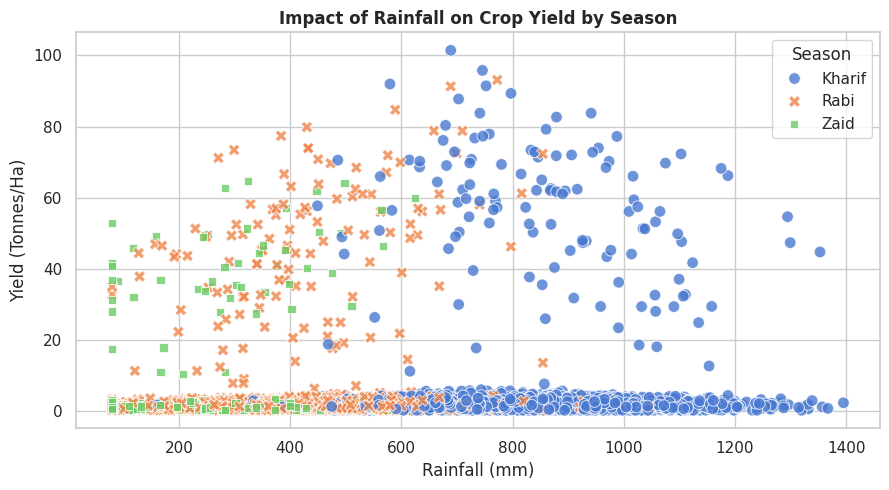

In [19]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    style="Season",
    s=70,
    alpha=0.8,
)
plt.title("Impact of Rainfall on Crop Yield by Season", fontweight="bold")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

#### 6.4 Correlation Matrix: Metric Interrelationships
Visualize linear relationship strengths across environmental, operational, and financial columns.

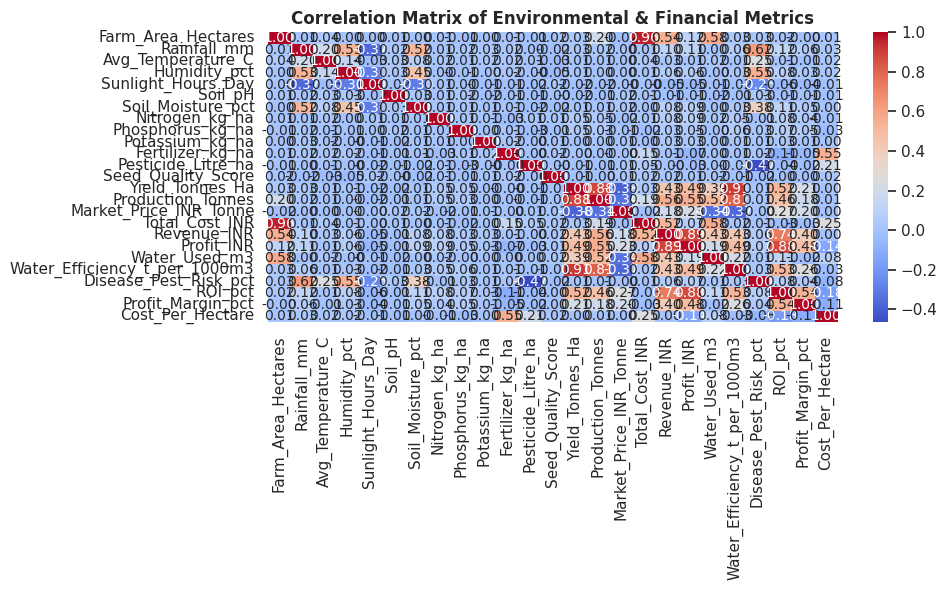

In [20]:
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title(
    "Correlation Matrix of Environmental & Financial Metrics",
    fontweight="bold",
)
plt.tight_layout()
plt.show()


### 7. Analytical Findings & Conclusions

* **Yield Variances:** Box plot distributions highlight distinct yield stability profiles across the `Kharif`, `Rabi`, and `Zaid` seasons.
* **Crop Economics:** Financial indicator calculations reveal which crop varieties generate the highest net profit relative to production costs.
* **Environmental Impact:** Correlation metrics and scatter plots demonstrate how climatic parameters like rainfall influence overall farm performance.
